In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

from dataset import SceneTwoPairsDataset
from model import PairImageCylinderModel
from losses import supervised_loss, consistency_loss, add_sup_losses

from debugger import bug_check


In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

CUDA available: True
NVIDIA GeForce RTX 5050 Laptop GPU


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = PairImageCylinderModel(
    img_size=128,
    patch_size=8,
    in_chans=3,
    embed_dim=384,
    depth=6,
    num_heads=6,
    num_bins=128,
    dropout=0.1,
).to(device)


In [5]:
dataset = SceneTwoPairsDataset(
    root_dir="dataset",
    image_size=128,
    debugg=False,
    return_two_pairs=True
)

loader = DataLoader(
    dataset,
    batch_size=6,
    shuffle=True,
    num_workers=0,
)

In [6]:
# bug_check(0)

In [7]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

# Hyperparameters
LAMBDA_CONS = 1.0
LAMBDA_OCC = 10.0
LAMBDA_RADIUS = 10.0
OCC_THRESH= 0.8

model.train()
for epoch in range(200):
    total = 0.0
    total_vis1 = 0.0
    total_radius1 = 0.0
    total_depth1 = 0.0
    total_pose1 = 0.0
    total_t1 = 0.0
    total_r1 = 0.0

    total_vis2 = 0.0
    total_radius2 = 0.0
    total_depth2 = 0.0
    total_pose2 = 0.0
    total_t2 = 0.0
    total_r2 = 0.0

    total_cons_loss = 0.0
    total_cons_occ = 0.0
    total_cons_rad = 0.0
    total_cons_dep = 0.0

    for batch in loader:
        # img_a1, vision_a1, img_b1, pose_ab1 = batch
        img_a1, vision_a1, img_b1, vision_b1, pose_ab1, img_a2, vision_a2, img_b2, vision_b2, pose_ab2 = batch

        img_a1 = img_a1.to(device, non_blocking=True)
        img_b1 = img_b1.to(device, non_blocking=True)
        vision_a1 = vision_a1.to(device, non_blocking=True)
        vision_b1 = vision_b1.to(device, non_blocking=True)
        pose_ab1 = pose_ab1.to(device, non_blocking=True)
        img_a2 = img_a2.to(device, non_blocking=True)
        img_b2 = img_b2.to(device, non_blocking=True)
        vision_a2 = vision_a2.to(device, non_blocking=True)
        vision_b2 = vision_b2.to(device, non_blocking=True)
        pose_ab2 = pose_ab2.to(device, non_blocking=True)

        pred_vision_a1, pred_vision_b1, pred_pose1 = model(img_a1, img_b1)
        pred_vision_a2, pred_vision_b2, pred_pose2 = model(img_a2, img_b2)

        loss_out1 = supervised_loss(pred_vision_a1, vision_a1, pred_vision_b1, vision_b1, pred_pose1, pose_ab1,
                                    occ_thresh=OCC_THRESH,
                                    lambda_occ=LAMBDA_OCC,
                                    lambda_radius=LAMBDA_RADIUS,
        )

        loss_out2 = supervised_loss(pred_vision_a2, vision_a2, pred_vision_b2, vision_b2, pred_pose2, pose_ab2,
                                    occ_thresh=OCC_THRESH,
                                    lambda_occ=LAMBDA_OCC,
                                    lambda_radius=LAMBDA_RADIUS,
        )

        cons_loss1, cons_occ1, cons_rad1, cons_dep1 = consistency_loss(
            pred_vision_a1,
            pred_vision_a2,
            occ_thresh=0.5,
            match_thresh=0.25,
        )

        cons_loss2, cons_occ2, cons_rad2, cons_dep2 = consistency_loss(
        pred_vision_b1,
        pred_vision_b2,
        occ_thresh=0.5,
        match_thresh=0.25,
        )

        loss = loss_out1["total"] + loss_out2["total"] + LAMBDA_CONS * (cons_loss1 + cons_loss2)/2.0

        #print(cons_loss)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        total += loss.item()

        total_vis1, total_radius1, total_pose1, total_depth1, total_t1, total_r1 = add_sup_losses(
            total_vis1, total_radius1, total_pose1, total_depth1, total_t1, total_r1, loss_out1
        )
        total_vis2, total_radius2, total_pose2, total_depth2, total_t2, total_r2 = add_sup_losses(
            total_vis2, total_radius2, total_pose2, total_depth2, total_t2, total_r2, loss_out2
        )

        total_cons_loss += cons_loss1.item()
        total_cons_occ += cons_occ1.item()
        total_cons_rad += cons_rad1.item()
        total_cons_dep += cons_dep1.item()

    n = len(loader)

    print(
        f"Epoch {epoch+1}: "
        f"tot={total/n:.4f} | "
        f"vis={total_vis1/n:.4f} | "
        f"r={total_radius1/n:.4f} | "
        f"d={total_depth1/n:.4f} | "
        f"pose={total_pose1/n:.4f} | "
        f"t={total_t1/n:.4f} | "
        f"r={total_r1/n:.4f} | "
        f"cons={total_cons_loss/n:.4f} | "
        f"occ={total_cons_occ/n:.4f} | "
        f"cons_r={total_cons_rad/n:.4f} | "
        f"cons_d={total_cons_dep/n:.4f}"
    )

Epoch 1: tot=35.5009 | vis=17.1730 | r=0.1782 | d=9.4733 | pose=0.3792 | t=0.2493 | r=0.1299 | cons=0.0246 | occ=0.0005 | cons_r=0.0117 | cons_d=0.0123
Epoch 2: tot=30.1823 | vis=14.9526 | r=0.1437 | d=9.5297 | pose=0.3144 | t=0.2520 | r=0.0624 | cons=0.0160 | occ=0.0000 | cons_r=0.0073 | cons_d=0.0086
Epoch 3: tot=26.3227 | vis=13.0161 | r=0.1363 | d=8.9844 | pose=0.3181 | t=0.2528 | r=0.0653 | cons=0.0000 | occ=0.0000 | cons_r=0.0000 | cons_d=0.0000
Epoch 4: tot=23.6288 | vis=11.5278 | r=0.1326 | d=8.0180 | pose=0.3141 | t=0.2509 | r=0.0631 | cons=0.0000 | occ=0.0000 | cons_r=0.0000 | cons_d=0.0000
Epoch 5: tot=21.1987 | vis=10.4998 | r=0.1310 | d=7.0707 | pose=0.3171 | t=0.2512 | r=0.0659 | cons=0.0000 | occ=0.0000 | cons_r=0.0000 | cons_d=0.0000
Epoch 6: tot=19.0919 | vis=9.2639 | r=0.1349 | d=5.8037 | pose=0.3145 | t=0.2535 | r=0.0610 | cons=0.0000 | occ=0.0000 | cons_r=0.0000 | cons_d=0.0000
Epoch 7: tot=17.6626 | vis=8.3275 | r=0.1343 | d=4.8799 | pose=0.3128 | t=0.2505 | r=0.06

In [11]:
# Inference + utskrift + plottar på samma dataset som träningen
from utils import pose_to_text, show_image_pair

infer_dataset = SceneTwoPairsDataset(
    root_dir="testdataset",
    return_two_pairs=False
)

infer_loader = DataLoader(
    infer_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
)
model.eval()

batch = next(iter(infer_loader))
img_a, vision_a, img_b, vision_b, pose_ab = batch

img_a = img_a.to(device)
vision_a = vision_a.to(device)
img_b = img_b.to(device)
pose_ab = pose_ab.to(device)

with torch.no_grad():
    pred_vision, _, pred_pose = model(img_a, img_b)

# Skriv ut resultat för några samples
n_show = min(4, img_a.shape[0])
for i in range(n_show):
    print(f"Sample {i}")
    print("  GT   pose:", pose_to_text(pose_ab[i].detach().cpu()))
    print("  Pred pose:", pose_to_text(pred_pose[i].detach().cpu()))

    pose_err = torch.abs(pred_pose[i] - pose_ab[i]).detach().cpu()
    print(f"  |err|     : tx={pose_err[0]:.3f}, ty={pose_err[1]:.3f}, sin={pose_err[2]:.3f}, cos={pose_err[3]:.3f}")
    print()

Sample 0
  GT   pose: tx=0.457, ty=-0.889, yaw=2.7°
  Pred pose: tx=-0.785, ty=0.166, yaw=-5.4°
  |err|     : tx=1.242, ty=1.055, sin=0.141, cos=0.003

Sample 1
  GT   pose: tx=0.621, ty=0.784, yaw=14.2°
  Pred pose: tx=0.280, ty=-0.701, yaw=6.9°
  |err|     : tx=0.340, ty=1.485, sin=0.125, cos=0.023

Sample 2
  GT   pose: tx=0.998, ty=0.060, yaw=17.2°
  Pred pose: tx=0.279, ty=-0.745, yaw=13.3°
  |err|     : tx=0.719, ty=0.805, sin=0.066, cos=0.018

Sample 3
  GT   pose: tx=-0.648, ty=0.761, yaw=22.5°
  Pred pose: tx=-0.268, ty=-0.154, yaw=-16.5°
  |err|     : tx=0.380, ty=0.915, sin=0.667, cos=0.034



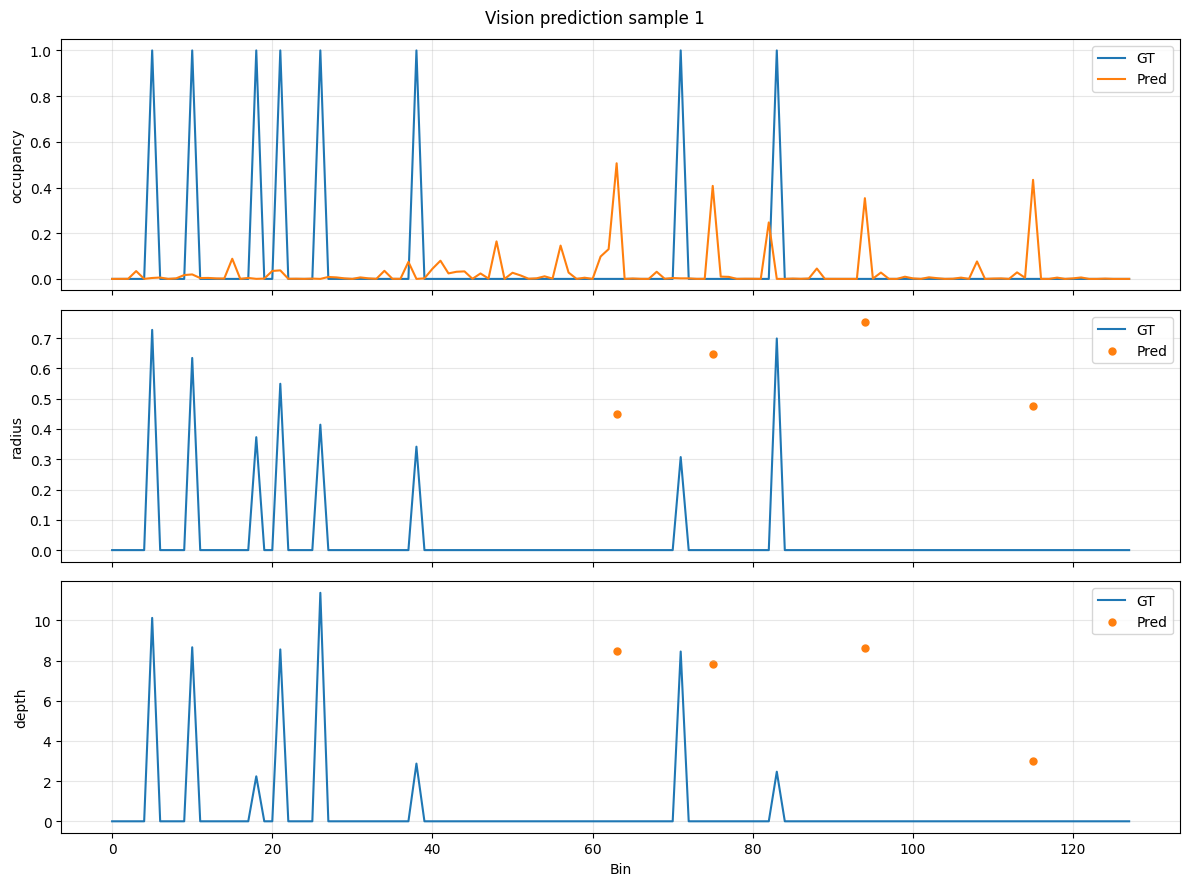

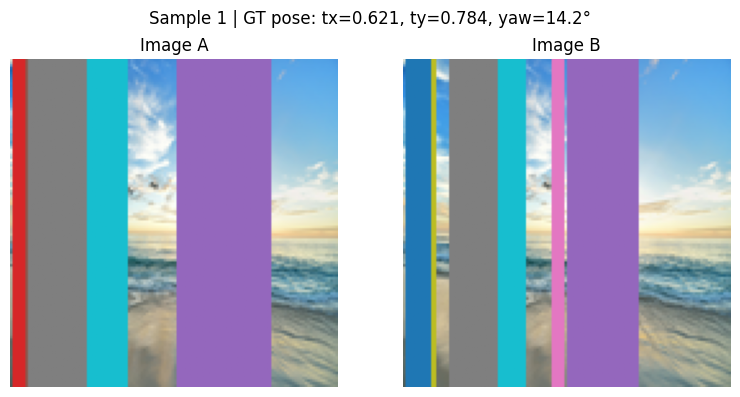

In [12]:
# Plotta vision-output för första samplet
sample_idx = 1
bins = np.arange(pred_vision.shape[1])

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

names = ["occupancy", "radius", "depth"]
occ_threshold = 0.3

gt_occ = vision_a[sample_idx, :, 0].detach().cpu().numpy()
pr_occ = pred_vision[sample_idx, :, 0].detach().cpu().numpy()

for j, ax in enumerate(axes):
    gt = vision_a[sample_idx, :, j].detach().cpu().numpy()
    pr = pred_vision[sample_idx, :, j].detach().cpu().numpy()

    # GT alltid blå linje
    ax.plot(bins, gt, label="GT", color="tab:blue")

    if j == 0:
        # occupancy: pred som orange linje
        ax.plot(bins, pr, label="Pred", color="tab:orange")
    else:
        pr_mask = pr_occ > occ_threshold

        # pred som orange punkter
        ax.scatter(
            bins[pr_mask],
            pr[pr_mask],
            label="Pred",
            color="tab:orange",
            s=25
        )

    ax.set_ylabel(names[j])
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Bin")
fig.suptitle(f"Vision prediction sample {sample_idx}")
plt.tight_layout()
plt.show()

# Plotta bildpar
show_image_pair(
    img_a[sample_idx].detach().cpu(),
    img_b[sample_idx].detach().cpu(),
    title=f"Sample {sample_idx} | GT pose: {pose_to_text(pose_ab[sample_idx].detach().cpu())}"
)

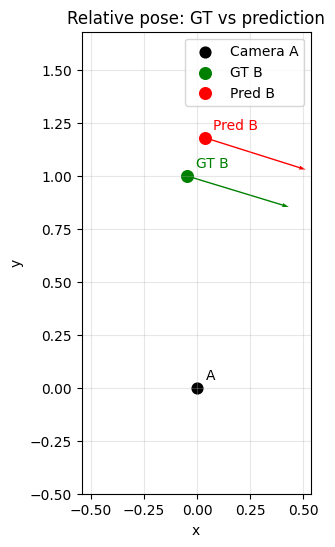

pred_vision shape: torch.Size([4, 128, 3])
pred_pose shape: torch.Size([4, 4])
GT pose: tensor([-0.0453,  0.9990, -0.2911,  0.9567])
Pred pose: tensor([ 0.0360,  1.1804, -0.3013,  0.9535])


In [10]:
import matplotlib.pyplot as plt
import torch
import numpy as np

from utils import plot_relative_pose


# Visa första paret i batchen
if False:
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(img_a[sample_idx].cpu().permute(1, 2, 0))
    axes[0].set_title("Image A")
    axes[0].axis("off")

    axes[1].imshow(img_b[sample_idx].cpu().permute(1, 2, 0))
    axes[1].set_title("Image B")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

# Visa relative pose
plot_relative_pose(pose_ab[sample_idx], pred_pose[sample_idx])

print("pred_vision shape:", pred_vision.shape)
print("pred_pose shape:", pred_pose.shape)
print("GT pose:", pose_ab[sample_idx].detach().cpu())
print("Pred pose:", pred_pose[sample_idx].detach().cpu())